In [1]:
import os
import collections
import xarray as xr
import numpy as np
import pandas as pd
import numpy.ma as ma
import metpy.calc as mpcalc
import subprocess

from datetime import datetime
from skimage.feature import peak_local_max
import cartopy.crs as ccrs
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt,lfilter
import datetime as dt
import xskillscore as xs
import xcdat as xc

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker

import matplotlib.colors as matcolors
import matplotlib.path as matpath
import matplotlib.ticker as mticker
import matplotlib.contour as mcontour

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

import cmaps as gvcmaps
import geocat.viz.util as gvutil
import geocat.viz as gv


In [2]:
def e3sm_constants():
    SHR_CONST_REARTH  = 6.37122e6
    SHR_CONST_G       = 9.80616
    SHR_CONST_PI      = 3.14159265358979323846
    SHR_CONST_BOLTZ   = 1.38065e-23
    SHR_CONST_STEBOL  = 5.67e-8
    SHR_CONST_AVOGAD  = 6.02214e26
    SHR_CONST_RGAS    = SHR_CONST_AVOGAD*SHR_CONST_BOLTZ # Universal gas constant ~ J/K/kmole
    SHR_CONST_MWDAIR  = 28.966  # molecular weight dry air ~ kg/kmole
    SHR_CONST_MWWV    = 18.016  # molecular weight water vapor
    SHR_CONST_RDAIR   = SHR_CONST_RGAS/SHR_CONST_MWDAIR  #! Dry air gas constant     ~ J/K/kg
    SHR_CONST_RWV     = SHR_CONST_RGAS/SHR_CONST_MWWV  #Water vapor gas constant ~ J/K/kg
    SHR_CONST_ZVIR    = (SHR_CONST_RWV/SHR_CONST_RDAIR)-1.0 #RWV/RDAIR - 1.0 
    SHR_CONST_PSTD    = 101325.0          # standard pressure ~ pascals
    SHR_CONST_TKFRZ   = 273.15       #freezing T of fresh water          ~ K
    SHR_CONST_TKTRIP  = 273.16       # triple point of fresh water
    SHR_CONST_RHODAIR = SHR_CONST_PSTD/(SHR_CONST_RDAIR*SHR_CONST_TKFRZ)    #           ! density of dry air at STP  ~ kg/m^3
    SHR_CONST_CPDAIR  = 1.00464e3    # specific heat of dry air   ~ J/kg/K
    SHR_CONST_CPWV    = 1.810e3      # specific heat of water vap ~ J/kg/K
    SHR_CONST_CPICE   = 2.11727e3    # specific heat of fresh ice ~ J/kg/K
    SHR_CONST_LATICE  = 3.337e5      # latent heat of fusion      ~ J/kg
    SHR_CONST_LATVAP  = 2.501e6      # latent heat of evaporation
    SHR_CONST_LATSUB  = SHR_CONST_LATICE + SHR_CONST_LATVAP #latent heat of sublimation ~ J/kg
if __name__ == "__main__":
    e3sm_constants()

In [3]:
def plot_boundaries(ax):
    """This function plots geographic and political boundaries on the provided axes."""
    # Plot coastlines and political boundaries
    #ax.add_feature(cfeature.STATES.with_scale('50m'), linewidths=0.5, linestyle='solid', edgecolor='k')
    #ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidths=1.0, linestyle='solid', edgecolor='k')
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidths=0.5, linestyle='solid', edgecolor='k')
            
    # Fill in continents in light gray
    #ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#EEEEEE', edgecolor='face')
    
    #load background figure
    #ax.stock_img()

    # Return axes instance
    return ax

In [4]:
def plot_gridlines(ax,projection):
    #Add gridlines and labels
    gl = ax.gridlines(crs=projection, draw_labels=True,
          linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlabels_top  = False
    gl.ylabels_left = False
    gl.xlines       = True
    gl.ylines       = True
    gl.xformatter   = cticker.LongitudeFormatter()
    gl.yformatter   = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': fontz*0.6, 'color': 'black'}
    gl.ylabel_style = {'size': fontz*0.6, 'color': 'black'}
    ax.xaxis.set_tick_params(labeltop=False)
    ax.yaxis.set_tick_params(labelright=False) 

In [5]:
def generate_coslat_weight(ds):
    # make weights as cosine of the latitude and broadcast
    weights = np.cos(np.deg2rad(ds.lat))
    _, weights = xr.broadcast(ds,weights)
    
    return weights

In [6]:
def define_region(regnam='global'):
    reg_dict = {'global':[(-90,90),(-180,180)],
                'Atlantic':[(0,60),(265,345)],
                'CONUS':[(25,50),(235,295)],
                'Antarctic':[(-90,-50),(-180,180)],
                'PolarN':[(50,90),(-180,180)],
                #'Greenland':[(59,83),(-74,-11)],
                'Greenland':[(55,90),(-75,-10)],
               }
    return reg_dict[regnam]
    

In [7]:
def draw_2d_map(iit,regnam,var_dict,df,fig_path,fgw=30,fgh=25,ws=0.5,hs=0.5):
    var_list = list(var_dict.keys())
    model_list = list(df.keys())
    
    nrows=len(var_dict)
    ncols=len(model_list)

    #create figure  
    frac = fgw/fgh * (25/30)
    fontz = 12 * frac
    data_projection = ccrs.PlateCarree() #ccrs.Robinson() #ccrs.PlateCarree()    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                             figsize=(fgw,fgh), 
                             subplot_kw={'projection': data_projection})

    #cmap = plt.get_cmap('RdBu_r')
    cax = np.empty((nrows,ncols), dtype=plt.Axes)
    contour = np.empty((nrows,ncols), dtype=mcontour.ContourSet)
    
    # Import the default color map
    #cmap = plt.get_cmap('RdBu_r')
    newcmp = gvcmaps.BlueYellowRed
    index = [5, 20,  35, 50, 65, 85, 95, 110, 120, 125, 130, 135, 150,  165, 180, 200, 210, 220, 235, 250 ]
    color_list = [newcmp[i].colors for i in index]

    #------------------------------------------------------------------------------
    # Colormap
    #
    # Generate a colormap with colors from dark blue to dark red with white in the middle.
    #------------------------------------------------------------------------------
    color_list4 = ['darkblue', 'lightblue', 'white', 'lightyellow', 'orange',  'firebrick']
    nodes = [0.0, 0.3, 0.5, 0.5, 0.8,  1.0]
    cmap = matcolors.LinearSegmentedColormap.from_list('mybluewhitered', list(zip(nodes, color_list4)))
    
    bbox_to_anchor=(0.0, 0, 1, 1)
    labelpad = 10
    xpos_str = 0.5
    ypos_str = 1.1
    
    #set the extent of the map
    region = define_region(regnam)
    latreg = list(region[0])
    lonreg = list(region[1])
    extent = [lonreg[0],lonreg[1],latreg[0],latreg[1]]
    #print(extent)
    #print(xxx)
    
    # draw filled contours.    
    for i,var in enumerate(var_list):
        vunt = var_dict[var]['unit']
        vnam = var_dict[var]['alias']
        vmin = var_dict[var]['min']
        vmax = var_dict[var]['max']
        nlev = var_dict[var]['nlev']
        clevs = np.linspace(vmin,vmax,nlev)
        for j,model in enumerate(model_list):
            lat = df[model][var]['lat'] 
            lon = df[model][var]['lon']            
            vtend = df[model][var][iit,:,:]
            if model == "NDGUVTQ": 
                dso = vtend.copy()
                dso = dso **2
                # Weighted spatial average
                weights = generate_coslat_weight(dso)
                rmso = dso.weighted(weights).mean(("lat", "lon")).values
                print("obs:",rmso)
                vref = vtend.copy()
                rmse = 0.0
                pcor = 1.0
                #metrics_str = "RMSE_norm: {:0.1f} \n PCOR: {:0.2f}".format(rmse,pcor)
                metrics_str = "PCOR: {:0.2f}".format(pcor)
            else: 
                if not np.all(vtend == 0):
                    weights = generate_coslat_weight(vtend)
                    rmse = xs.rmse(vref,vtend, dim=["lat", "lon"], weights=weights.astype("float64"),skipna=True)
                    pcor = xs.pearson_r(vref,vtend, dim=["lat", "lon"], weights=weights.astype("float64"),skipna=True)
                    rmse = rmse / rmso
                    #metrics_str = "RMSE_norm: {:0.1f} \n PCOR: {:0.2f}".format(rmse.values,pcor.values)
                    metrics_str = "PCOR: {:0.2f}".format(pcor.values)

                else:
                    #metrics_str = "RMSE_norm: NA \n PCOR: NA"
                    metrics_str = "PCOR: NA"

            print(var,model,metrics_str)

            
            #print(vtend.min(),vtend.max())
            k = i * ncols + j

            #------------------------------------------------------------------------------
            # Set data bounds, norm and colorbar labels.
            #------------------------------------------------------------------------------
            cbar_labels = [f'{x:.1f}' for x in clevs]
            cbar_title = '{} ({})'.format(var,vunt)
            norm = matcolors.BoundaryNorm(clevs, cmap.N)
            #norm = matplotlib.colors.BoundaryNorm(np.linspace(vmin, vmax,nlev), nlev-1 )

            #plot_boundaries(axes.flat[k])
            #axes.flat[k].add_feature(cfeature.LAND, facecolor='lightgray')
            axes.flat[k].set_extent(extent, ccrs.PlateCarree())
            axes.flat[k].add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
            axes.flat[k].coastlines()
            axes.flat[k].add_feature(cfeature.LAKES,linewidth=0.5,edgecolor='black',facecolor='None',zorder=4)            
            
            # Manipulate latitude and longitude gridline numbers and spacing
            #gl.ylocator = mticker.FixedLocator(np.arange(extent[2],extent[3], 10))
            #gl.xlocator = mticker.FixedLocator(np.arange(extent[0],extent[1], 10))
            #gl.xlabels_top = False
            #gl.ylabels_right = False
            # Use geocat-viz utility function to format lat/lon tick labels
            gv.add_lat_lon_ticklabels(ax=axes.flat[k])
            
            # Use geocat.viz.util convenience function to add minor and major tick lines
            #gvutil.add_major_minor_ticks(axes.flat[k],
            #                             x_minor_per_major=2,
            #                             y_minor_per_major=2, 
            #                             labelsize=fontz*0.95)
            
            # Use geocat-viz utility function to customize tick marks
            gv.set_axes_limits_and_ticks(axes.flat[k],
                                         xlim=(extent[0], extent[1]),
                                         ylim=(extent[2], extent[3]),
                                         xticks=range(extent[0], extent[1]+1, 90),
                                         yticks=range(extent[2], extent[3]+1, 45))

            kwargs = dict(
                vmin = vmin,
                vmax = vmax,
                levels = clevs,
                colors=cmap, #color_list,
                add_colorbar=False,
                extend='both',
                transform=ccrs.PlateCarree(),  # ds projection
                zorder=0
            )            

            # Plot filled contours
            # fillplot = axes.flat[k].contourf(lon,lat,vplt, norm=norm, **kwargs)
            # fillplot = vplt.plot.contourf(ax=axes.flat[k],**kwargs)
            # fillplot = vtend.plot.contourf(ax=axes.flat[k],**kwargs)
            contour[i][j] = vtend.plot.contourf(ax=axes.flat[k], **kwargs)
            
            # Make a filled contour plot
            # Contouf-plot U data (for filled contours)
            #fillplot = axes.flat[k].contourf(lon,lat,vtend, norm=norm, **kwargs)
            #fillplot = vtend.plot.contourf(ax=axes.flat[k],**kwargs)
            
            #cax[i][j] = inset_axes(axes.flat[k],
            #                        width='5%',
            #                        height='90%',
            #                        loc='lower right',
            #                        bbox_to_anchor=bbox_to_anchor,
            #                        bbox_transform=axes.flat[k].transAxes,
            #                        borderpad=0)
            #cbar = plt.colorbar(contour[i][j], 
            #                    cax=cax[i][j], 
            #                    cmap=cmap,
            #                    norm=norm,
            #                    extend='both',
            
            #fig.subplots_adjust(top=0.2,right=0.01)
            cbar = plt.colorbar(contour[i][j], 
                                #cax=cax[i][j], #turn on if vertical
                                cmap=cmap,
                                norm=norm,
                                extend='both',
                                orientation='horizontal')
            #cbar.set_label(cbar_title, rotation=270, labelpad=labelpad,weight='normal',fontsize=fontz*1.2)
            cbar.set_label(cbar_title,labelpad=labelpad,weight='normal',fontsize=fontz*1.2)
            cbar.ax.tick_params(labelsize=fontz*1.1)
            cbar.set_ticklabels(cbar_labels, weight='normal')
            cbar.solids.set(edgecolor='black', linewidth=0.2)
            cbar.outline.set(edgecolor='black', linewidth=0.2)
            
            # Create colorbar
            #cb = plt.colorbar(fillplot,ax=axes.flat[k],
            #                  #ticks=np.linspace(vmin, vmax, nlev),
            #                  drawedges=True,
            #                  extendfrac='auto',
            #                  extendrect=True,
            #                  norm = norm,
            #                  orientation='horizontal',
            #                  format="{x:.2f}",
            #                  pad=0.02,
            #                  aspect=30*frac,
            #                  shrink=1.3*frac)
            #cb.set_label(label='{}({})'.format(var,vunt),fontsize=fontz*1.1)
            #cb.set_ticks(ticks=clevs,labels=clevs,fontsize=fontz*1.1)
            #tick_locator = ticker.MaxNLocator(nbins=4)
            #cb.locator = tick_locator
            #cb.update_ticks()
            #labels = []
            #for i,tick in enumerate(clevs):
            #    if i % 5 == 0:
            #        labels.append('{:.2f}'.format(clevs[i]))
            #    else:
            #        labels.append('')
            #cb.set_ticks(ticks=clevs,labels=labels,fontsize=fontz*frac*0.90)
            #cb.set_label(label=var,fontsize=fontz*frac*0.90)
            
            # Customize ticks and labels
            axes.flat[k].tick_params(labelsize=fontz*1.1, length=8)
            axes.flat[k].set_xlabel("")
            axes.flat[k].set_ylabel("")      
            axes.flat[k].tick_params(top=False, right=False)

            #axes.flat[k].set_title('{}'.format(var),loc='left',fontsize=fontz*1.2,pad=20)
            #axes.flat[k].set_title('{}'.format(metrics_str),loc='right',fontsize=fontz*1.2,pad=20)
            axes.flat[k].set_title('{} ({})'.format(model,metrics_str),loc='center',fontsize=fontz*1.2,pad=10)
            #axes.flat[k].text(1,1,metrics_str,fontsize=fontz*1.2, color='red', fontweight='bold', ha='center', va='center') #transform=plt.gcf().transFigure)
            #axes.flat[k].text(xpos_str,ypos_str,metrics_str,color='red',fontsize=fontz,fontweight='bold',ha='center',va='center',transform=axes.flat[k].transAxes)
            
        #plt.show()
        #print(xxx)
    #plt.tight_layout()
    plt.subplots_adjust(hspace=hs)
    plt.subplots_adjust(wspace=ws)
    plt.show()
    fig.savefig('fig_2d_map_{}_{}_{:05d}.png'.format('offline',var,iit))
    return 

In [8]:
def extract_offline_exp_info():
    exp_dict  = {
                'NDGUVTQ': {
                             'run': '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/input',
                             'prefix': 'ml_input',
                             'period': '20090001-20090005'
                },
                'UNET': {
                             'run': '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/UNET/v0/output',
                             'prefix': 'ML_PREDICT',
                             'period': '20090001-20090005'
                 },
                 'ResUNET': {
                             'run': '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/ResUNET/v0/output',
                             'prefix': 'ML_PREDICT',
                             'period': '20090001-20090005'
                 },
                 'IUNET': {
                             'run': '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/IUNET/v0/output',
                             'prefix': 'ML_PREDICT',
                             'period': '20090001-20090005'
                 },
                 'IUNET_LatLon': {
                             'run': '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/IUNET/v0_latlon/output',
                             'prefix': 'ML_PREDICT',
                             'period': '20090001-20090005'
                 },
                 'IUNET_Scalar': {
                             'run': '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/IUNET/v0_scalar/output',
                             'prefix': 'ML_PREDICT',
                             'period': '20090001-20090005'
                 },
                }
    return exp_dict

In [9]:
def extract_ml_prediction(tstart,tend,exp_dict,out_path):
    var_dict = {'Nudge_U':   {'alias': 'UTEND','unit':'kg m$^{-1}$ s$^{-1}$','fscl': 1.0,    'min': -0.2, 'max': 0.2, 'nlev': 11},
                'Nudge_V':   {'alias': 'VTEND','unit':'kg m$^{-1}$ s$^{-1}$','fscl': 1.0,    'min': -0.2, 'max': 0.2, 'nlev': 11},
                'Nudge_T':   {'alias': 'TTEND','unit':'K kg m$^{-2}$',       'fscl': 1.0,    'min': -0.2, 'max': 0.2, 'nlev': 11},
                'Nudge_Q':   {'alias': 'QTEND','unit':'mm day$^{-1}$',       'fscl': 86400.0,'min': -2,   'max': 2,   'nlev': 11}       
               }
    # mapping file for regriding
    maps = "/global/cfs/cdirs/e3sm/diagnostics/maps/map_ne30pg2_to_cmip6_180x360_aave.20200201.nc"
    rgdscpt = "/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/run_rgd.bash"
    #derive layer thickness
    fcoord = '/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb/input/coord.nc'
    ds = xr.open_mfdataset(fcoord)
    hyam = ds["hyai"]
    hybm = ds["hybi"]
    P0 =  ds["P0"]
    ps = ds["PS_bf_ndg"]
    nlev = len(hyam)
    ntime,ncol=np.shape(ps)
    plevp1 = np.zeros(shape=(ntime,nlev,ncol))
    for k in range(len(hyam)):
        plevp1[:,k,:] = hyam[k]*P0 + hybm[k]*ps[:,:]
    g  = 9.80665 
    dplev = (plevp1[:,1:nlev,:]-plevp1[:,0:nlev-1,:]) / g
    
    print(dplev.shape)
    print(dplev.min(),dplev.max())
    data_dict = dict()
    for var in var_dict.keys():
        print("working on var", var)
        varin = var_dict[var]['alias']
        vscal = var_dict[var]['fscl']
        for exp in exp_dict.keys():
            if exp not in data_dict.keys(): 
                data_dict[exp] = dict()
            if var not in data_dict[exp].keys():
                data_dict[exp][var] = dict()
            out_file = os.path.join(out_path,'{}_180x360_{}_{}_{}.nc'.format(var,exp,tstart,tend)) 
            if not os.path.exists(out_file):
                print("working on exp", exp)
                fpath = exp_dict[exp]['run']
                prefix = exp_dict[exp]['prefix']
                period = exp_dict[exp]['period']
                if exp in ['NDGUVTQ','NDGUVT','NDGUV']:
                    timestr = period[0:4]
                    fin = os.path.join(fpath,'{}_{}_{}.nc'.format(prefix,varin,timestr)) 
                    xs  = xr.open_mfdataset(fin)
                    dx = np.sum(xs[varin][0:5,:,:] * dplev[0:5,:,:],axis=1) * vscal
                    dx = dx.rename(var)
                else:
                    timestr = period[0:4]
                    fin = os.path.join(fpath,'{}_{}.{}*.nc'.format(prefix,var,timestr)) 
                    xs = xr.open_mfdataset(fin,concat_dim=[pd.Index(np.arange(5), name="time"),],combine="nested",)
                    dx = np.sum(xs[var][0:5,:,:] * dplev[0:5,:,:],axis=1) * vscal
                out_fil0 = out_file.replace('180x360','ne30pg2')
                dx.to_netcdf(out_fil0)
                #subprocess.run(['cp',rgdscpt,'./run_rgd.bash'])
                #subprocess.run(['chmod', '-x', './run_rgd.bash'])
                subprocess.call(['sh','./run_rgd.bash', out_fil0, out_file])
                
            ds = xr.open_mfdataset(out_file)
            data_dict[exp][var] = ds[var]
    return data_dict, var_dict

(17, 72, 21600)
0.4859031342624226 419.5551073947757
working on var Nudge_U
working on var Nudge_V
working on var Nudge_T
working on var Nudge_Q
obs: 0.02021497628793524
Nudge_U NDGUVTQ PCOR: 1.00
Nudge_U UNET PCOR: 0.32
Nudge_U ResUNET PCOR: 0.31
Nudge_U IUNET PCOR: 0.44
Nudge_U IUNET_LatLon PCOR: 0.43
Nudge_U IUNET_Scalar PCOR: 0.50
obs: 0.018807542260864445
Nudge_V NDGUVTQ PCOR: 1.00
Nudge_V UNET PCOR: 0.23
Nudge_V ResUNET PCOR: 0.23
Nudge_V IUNET PCOR: 0.48
Nudge_V IUNET_LatLon PCOR: 0.47
Nudge_V IUNET_Scalar PCOR: 0.51
obs: 0.011908577662221335
Nudge_T NDGUVTQ PCOR: 1.00
Nudge_T UNET PCOR: 0.51
Nudge_T ResUNET PCOR: 0.55
Nudge_T IUNET PCOR: 0.67
Nudge_T IUNET_LatLon PCOR: 0.66
Nudge_T IUNET_Scalar PCOR: 0.68
obs: 5.986974203468201
Nudge_Q NDGUVTQ PCOR: 1.00
Nudge_Q UNET PCOR: 0.39
Nudge_Q ResUNET PCOR: 0.39
Nudge_Q IUNET PCOR: 0.53
Nudge_Q IUNET_LatLon PCOR: 0.52
Nudge_Q IUNET_Scalar PCOR: 0.58


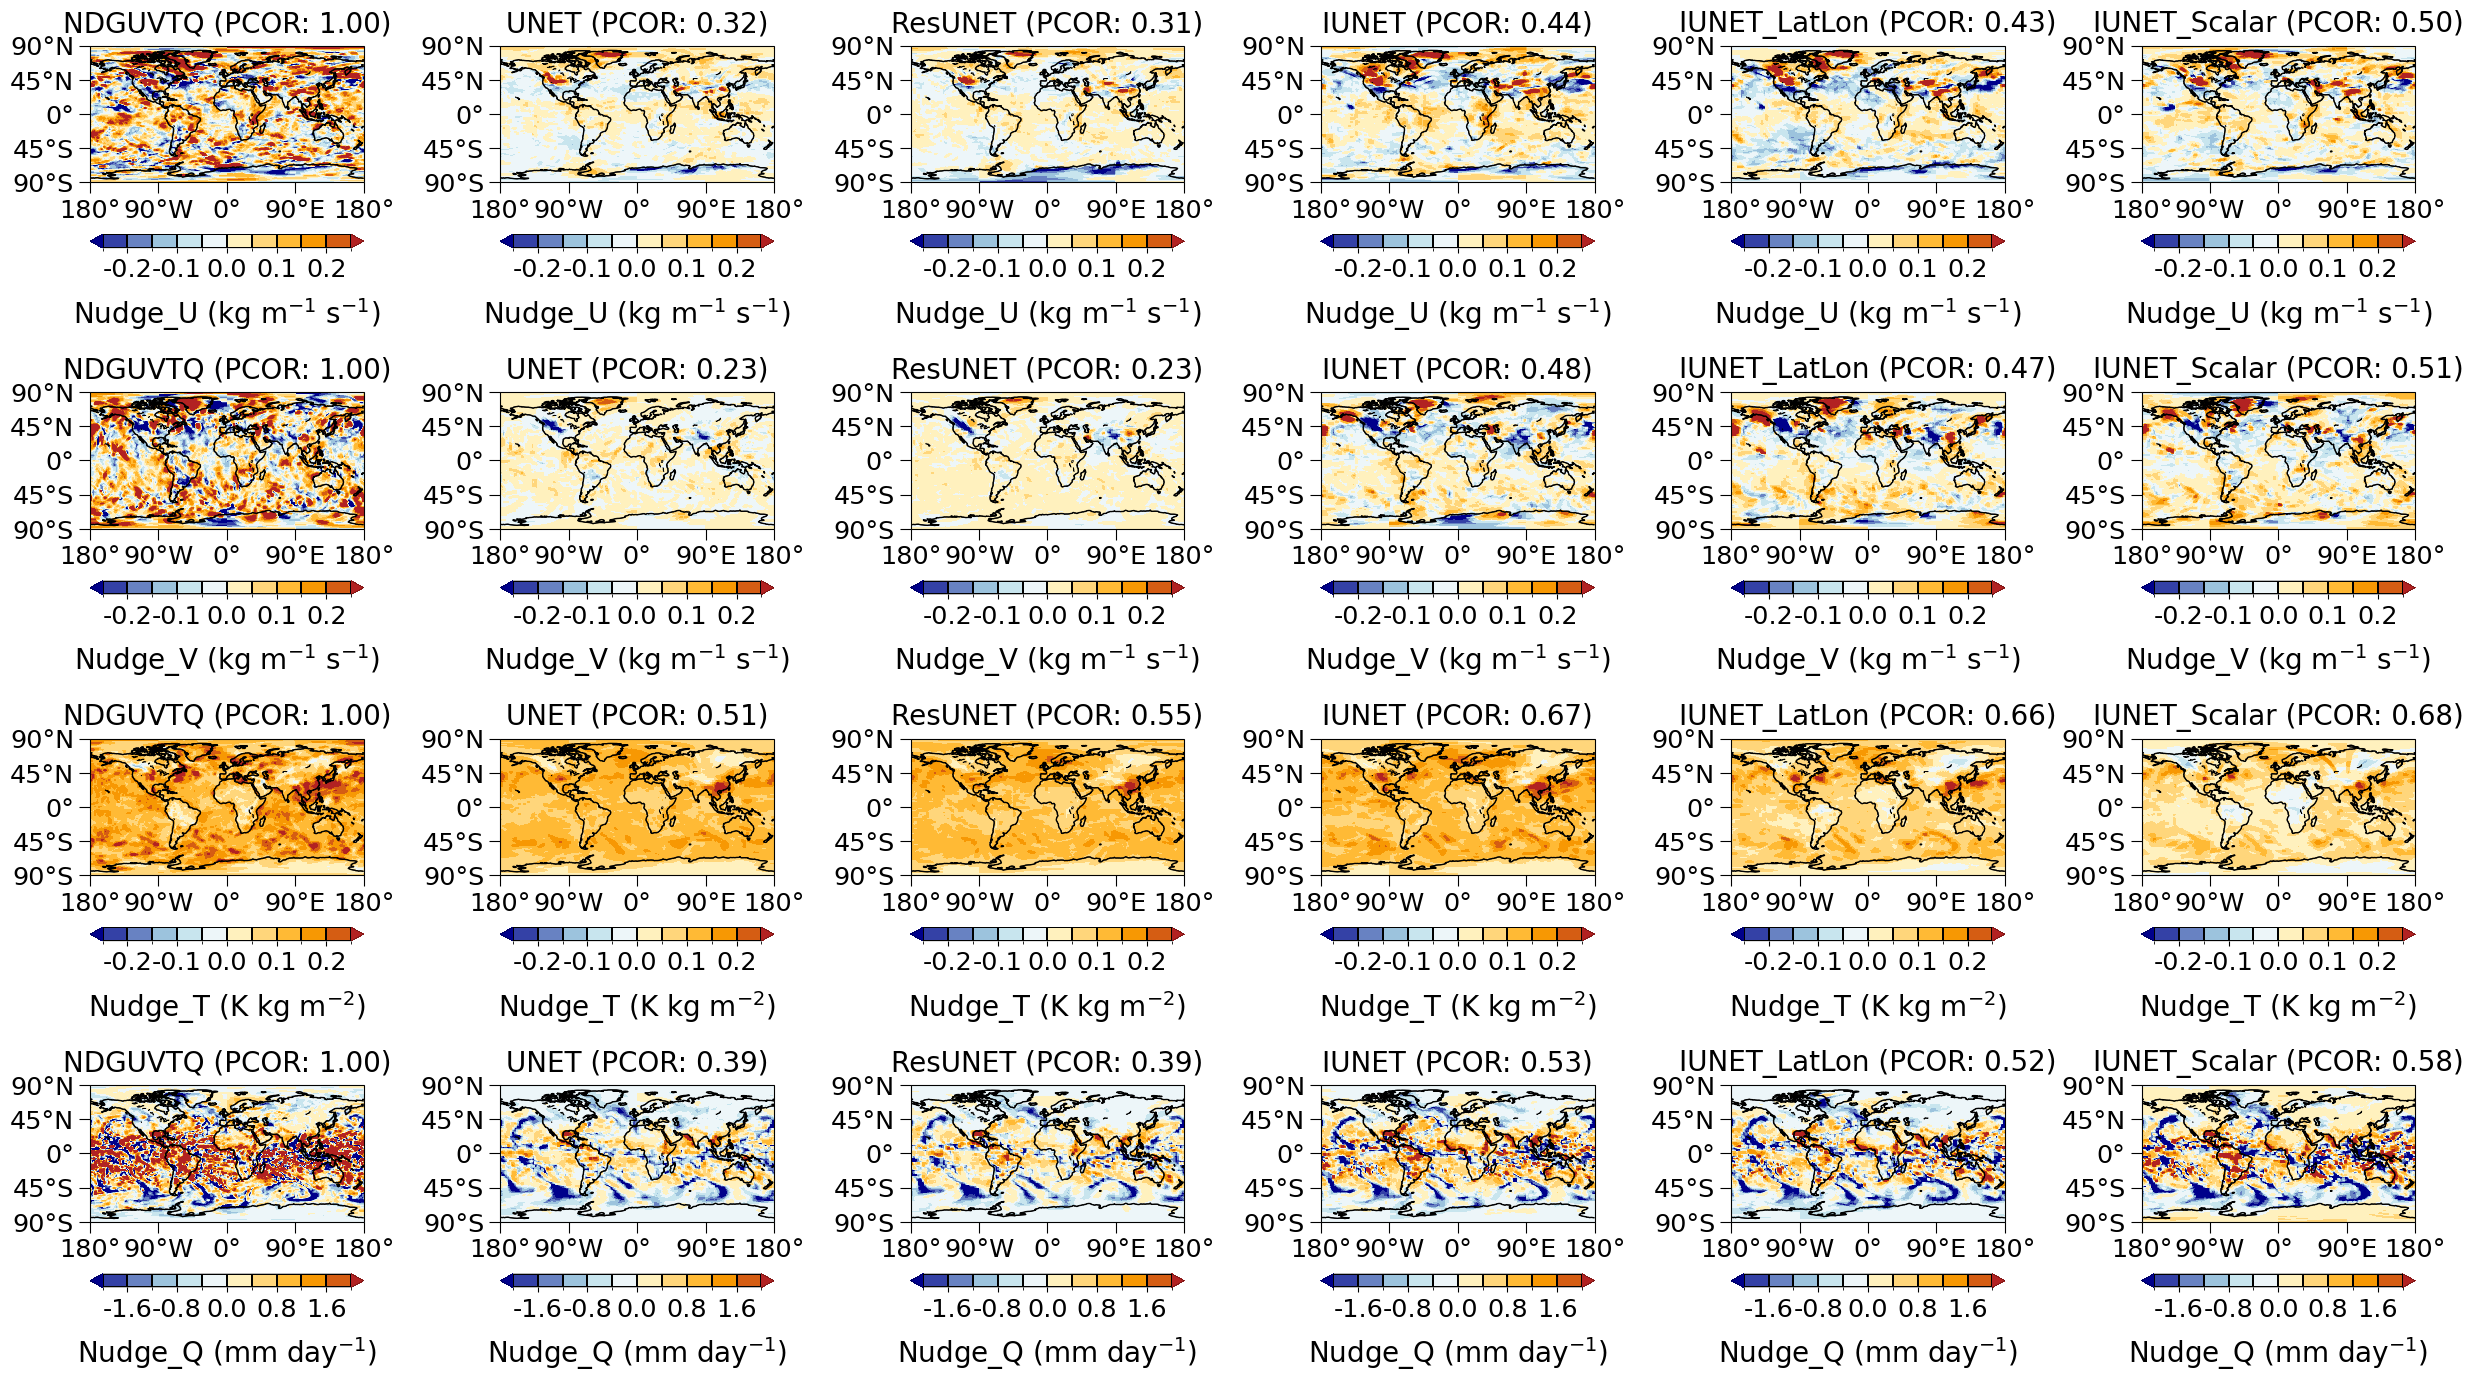

obs: 0.017426271511265235
Nudge_U NDGUVTQ PCOR: 1.00
Nudge_U UNET PCOR: 0.31
Nudge_U ResUNET PCOR: 0.30
Nudge_U IUNET PCOR: 0.44
Nudge_U IUNET_LatLon PCOR: 0.43
Nudge_U IUNET_Scalar PCOR: 0.43
obs: 0.01552919523849063
Nudge_V NDGUVTQ PCOR: 1.00
Nudge_V UNET PCOR: 0.24
Nudge_V ResUNET PCOR: 0.25
Nudge_V IUNET PCOR: 0.45
Nudge_V IUNET_LatLon PCOR: 0.45
Nudge_V IUNET_Scalar PCOR: 0.46
obs: 0.011346954548533756
Nudge_T NDGUVTQ PCOR: 1.00
Nudge_T UNET PCOR: 0.48
Nudge_T ResUNET PCOR: 0.55
Nudge_T IUNET PCOR: 0.65
Nudge_T IUNET_LatLon PCOR: 0.65
Nudge_T IUNET_Scalar PCOR: 0.67
obs: 5.057791699937397
Nudge_Q NDGUVTQ PCOR: 1.00
Nudge_Q UNET PCOR: 0.39
Nudge_Q ResUNET PCOR: 0.38
Nudge_Q IUNET PCOR: 0.52
Nudge_Q IUNET_LatLon PCOR: 0.52
Nudge_Q IUNET_Scalar PCOR: 0.49


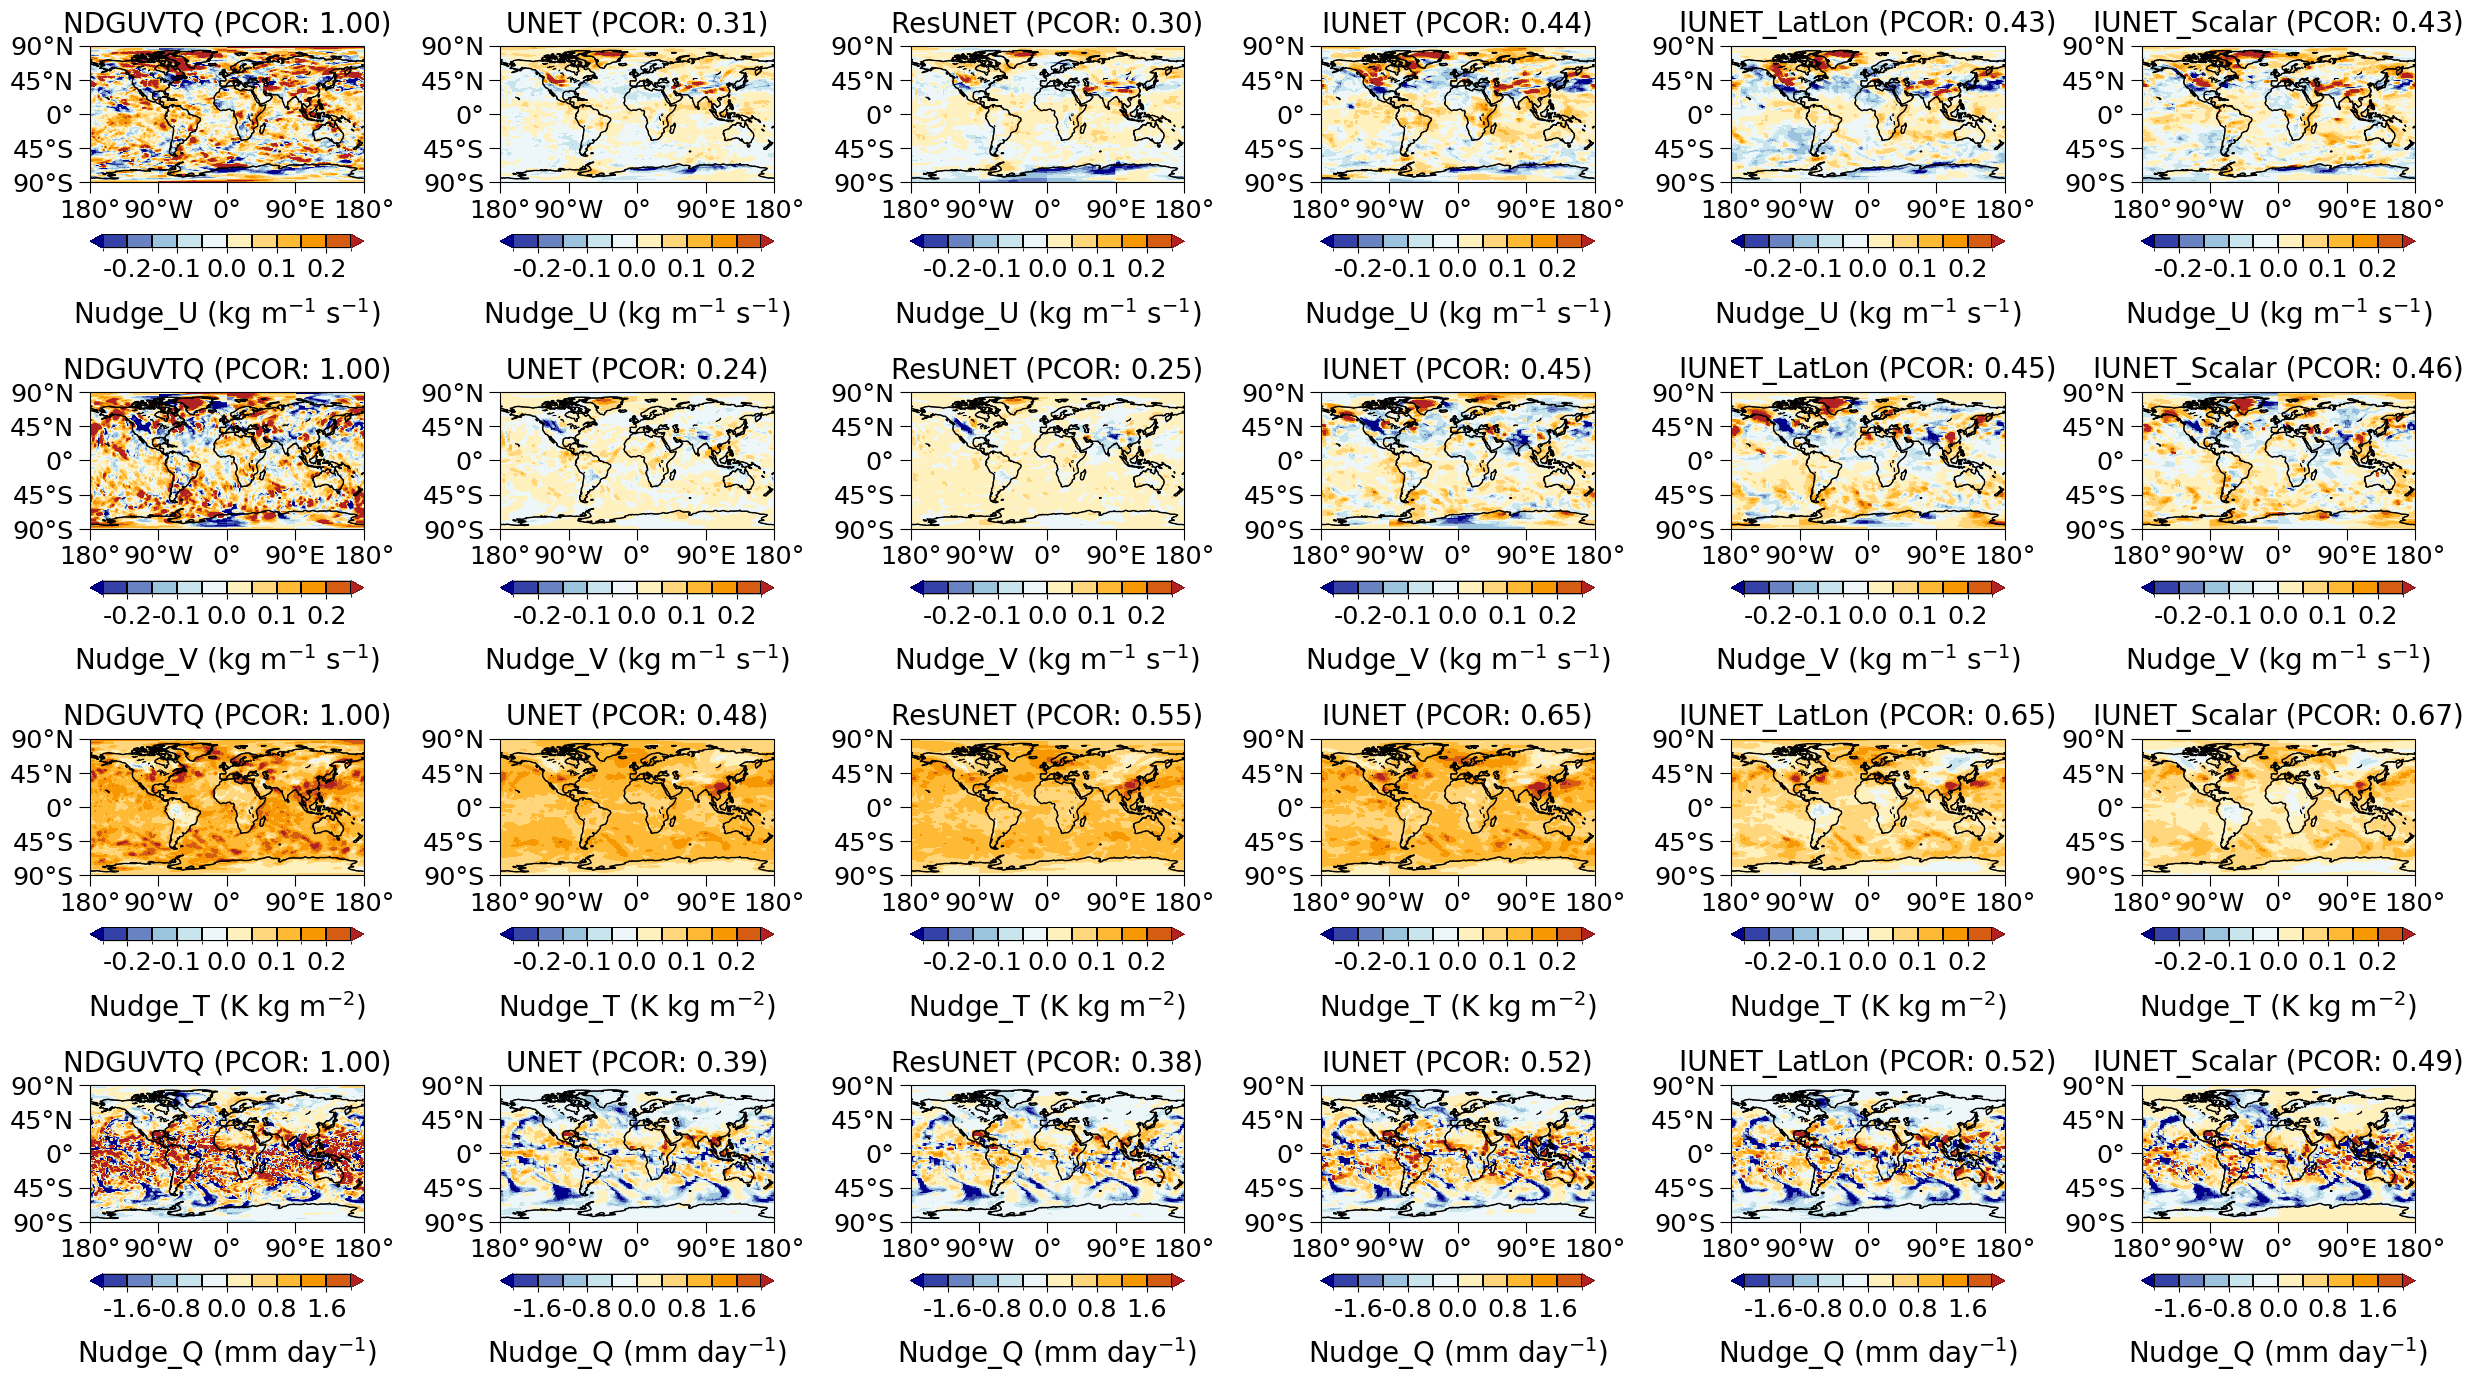

obs: 0.016026630064187763
Nudge_U NDGUVTQ PCOR: 1.00
Nudge_U UNET PCOR: 0.29
Nudge_U ResUNET PCOR: 0.30
Nudge_U IUNET PCOR: 0.42
Nudge_U IUNET_LatLon PCOR: 0.42
Nudge_U IUNET_Scalar PCOR: 0.42
obs: 0.013999823119732763
Nudge_V NDGUVTQ PCOR: 1.00
Nudge_V UNET PCOR: 0.24
Nudge_V ResUNET PCOR: 0.24
Nudge_V IUNET PCOR: 0.43
Nudge_V IUNET_LatLon PCOR: 0.45
Nudge_V IUNET_Scalar PCOR: 0.43
obs: 0.01106585180745581
Nudge_T NDGUVTQ PCOR: 1.00
Nudge_T UNET PCOR: 0.48
Nudge_T ResUNET PCOR: 0.55
Nudge_T IUNET PCOR: 0.65
Nudge_T IUNET_LatLon PCOR: 0.65
Nudge_T IUNET_Scalar PCOR: 0.66
obs: 4.6739795868594305
Nudge_Q NDGUVTQ PCOR: 1.00
Nudge_Q UNET PCOR: 0.40
Nudge_Q ResUNET PCOR: 0.38
Nudge_Q IUNET PCOR: 0.52
Nudge_Q IUNET_LatLon PCOR: 0.54
Nudge_Q IUNET_Scalar PCOR: 0.47


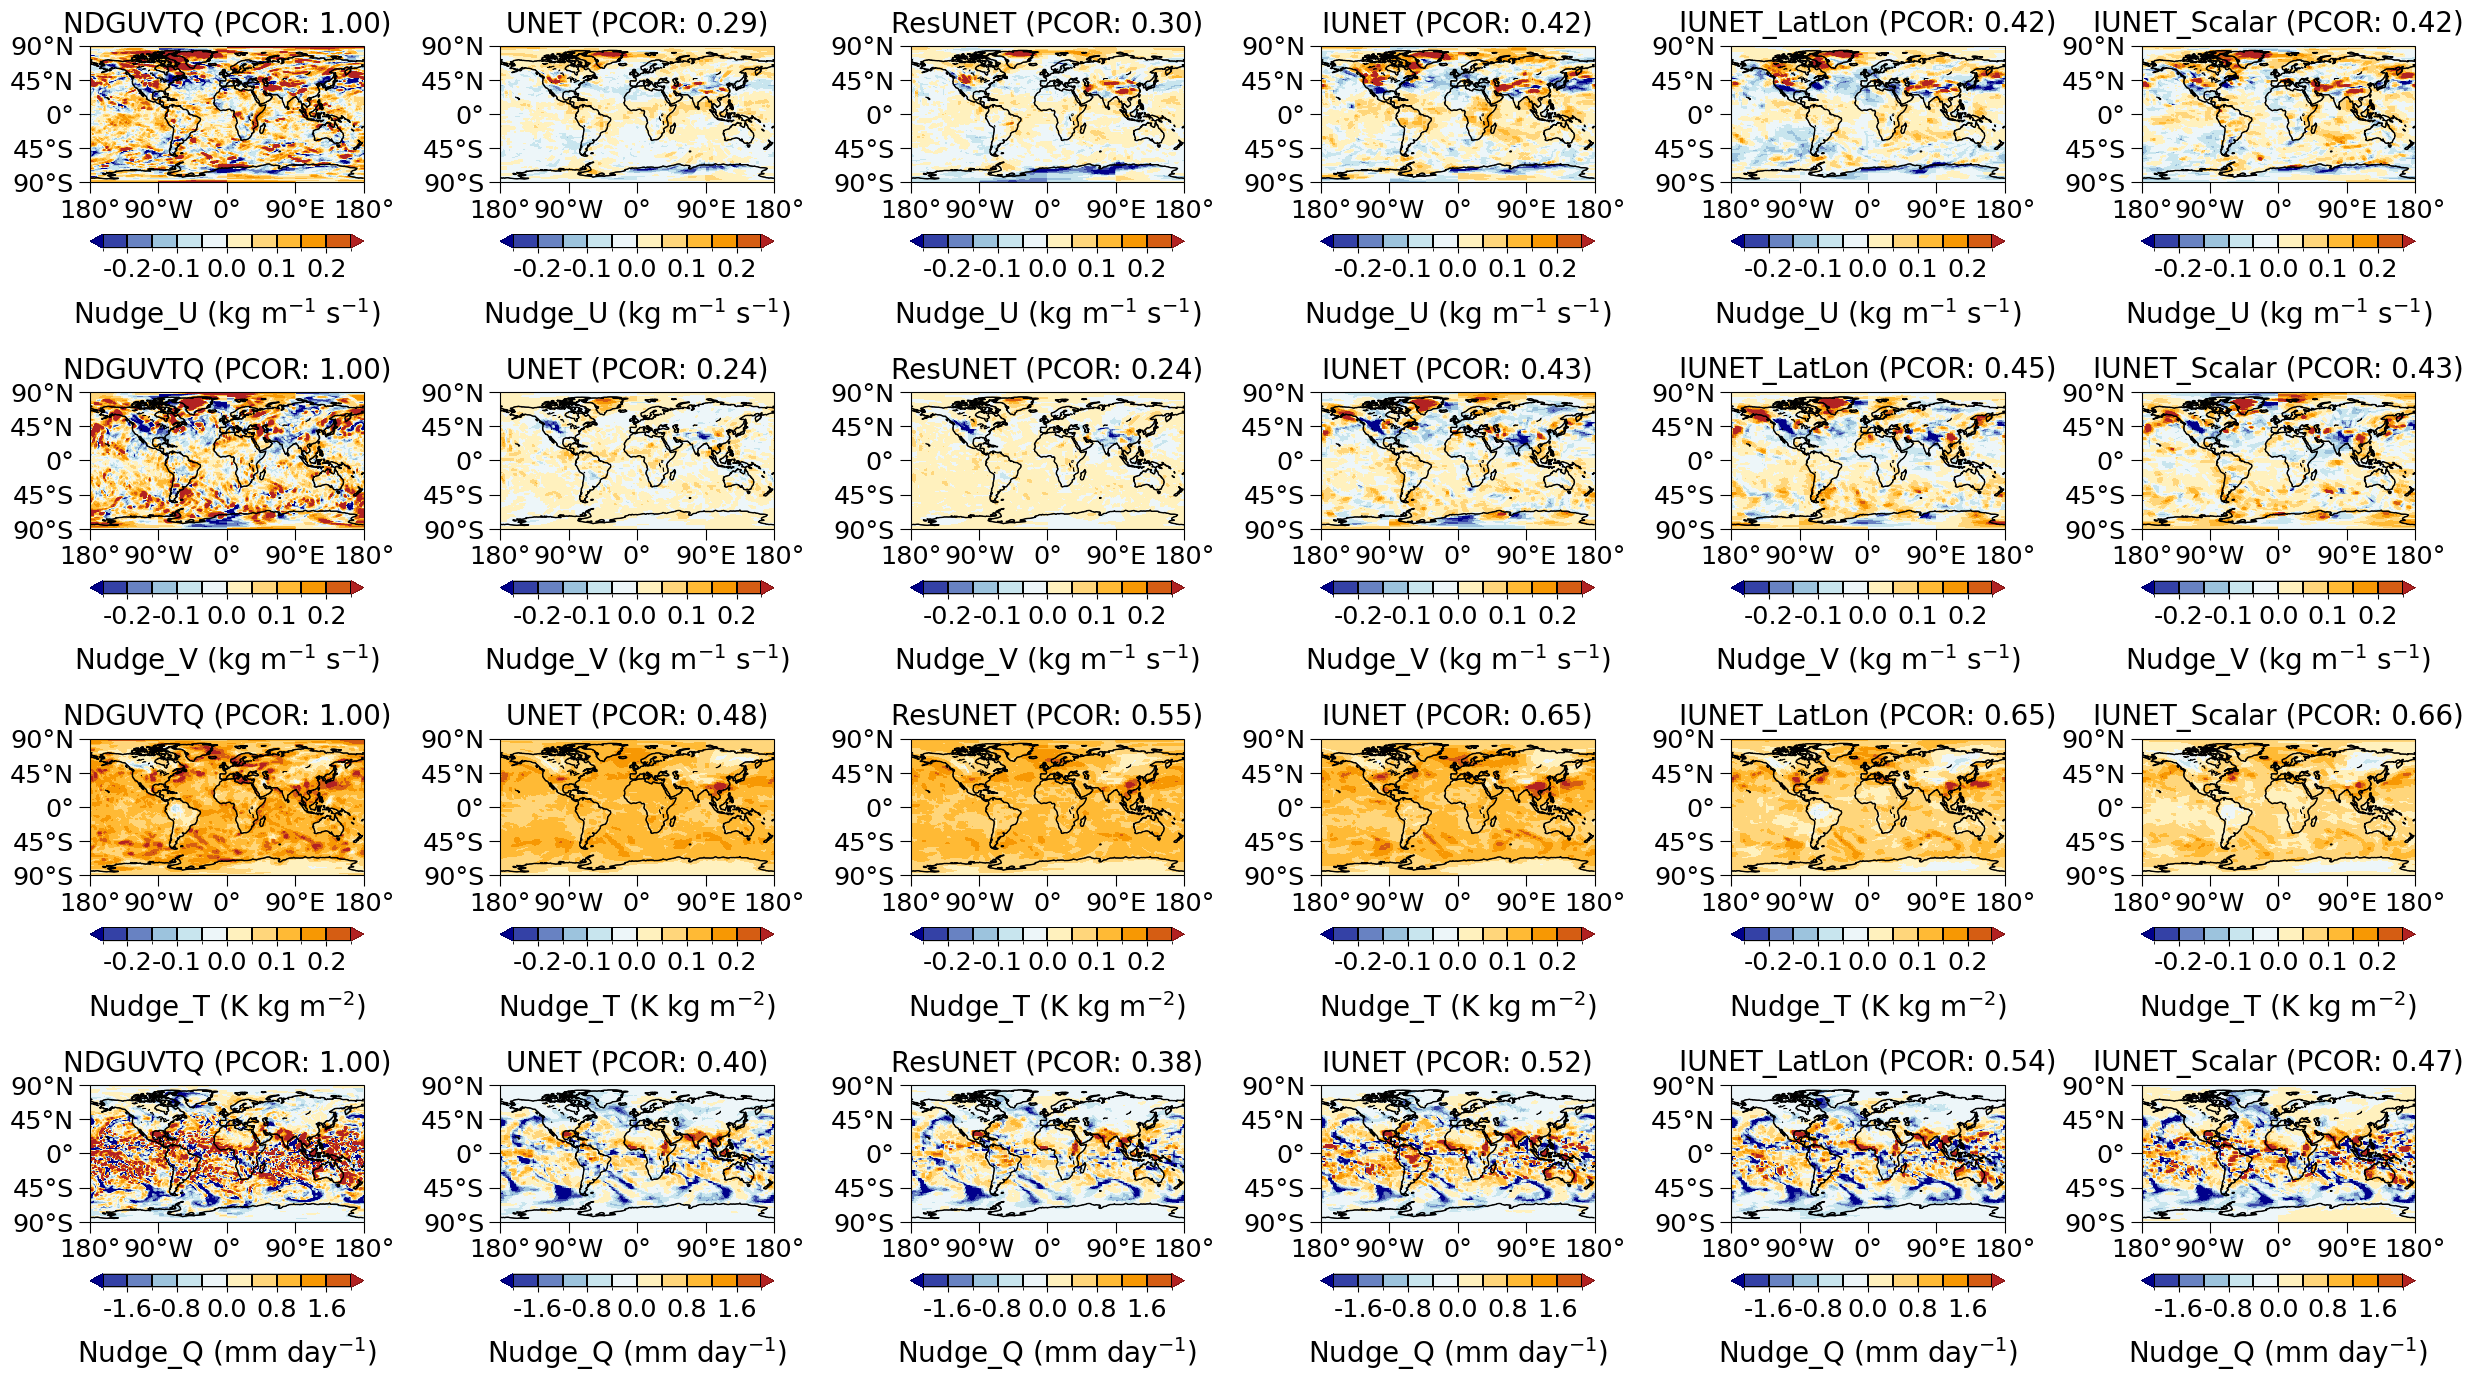

obs: 0.020075567144753326
Nudge_U NDGUVTQ PCOR: 1.00
Nudge_U UNET PCOR: 0.25
Nudge_U ResUNET PCOR: 0.29
Nudge_U IUNET PCOR: 0.39
Nudge_U IUNET_LatLon PCOR: 0.38
Nudge_U IUNET_Scalar PCOR: 0.38
obs: 0.017544931249186806
Nudge_V NDGUVTQ PCOR: 1.00
Nudge_V UNET PCOR: 0.16
Nudge_V ResUNET PCOR: 0.17
Nudge_V IUNET PCOR: 0.35
Nudge_V IUNET_LatLon PCOR: 0.38
Nudge_V IUNET_Scalar PCOR: 0.38
obs: 0.011949075728907166
Nudge_T NDGUVTQ PCOR: 1.00
Nudge_T UNET PCOR: 0.45
Nudge_T ResUNET PCOR: 0.52
Nudge_T IUNET PCOR: 0.61
Nudge_T IUNET_LatLon PCOR: 0.59
Nudge_T IUNET_Scalar PCOR: 0.60
obs: 6.068813819014764
Nudge_Q NDGUVTQ PCOR: 1.00
Nudge_Q UNET PCOR: 0.37
Nudge_Q ResUNET PCOR: 0.38
Nudge_Q IUNET PCOR: 0.48
Nudge_Q IUNET_LatLon PCOR: 0.48
Nudge_Q IUNET_Scalar PCOR: 0.40


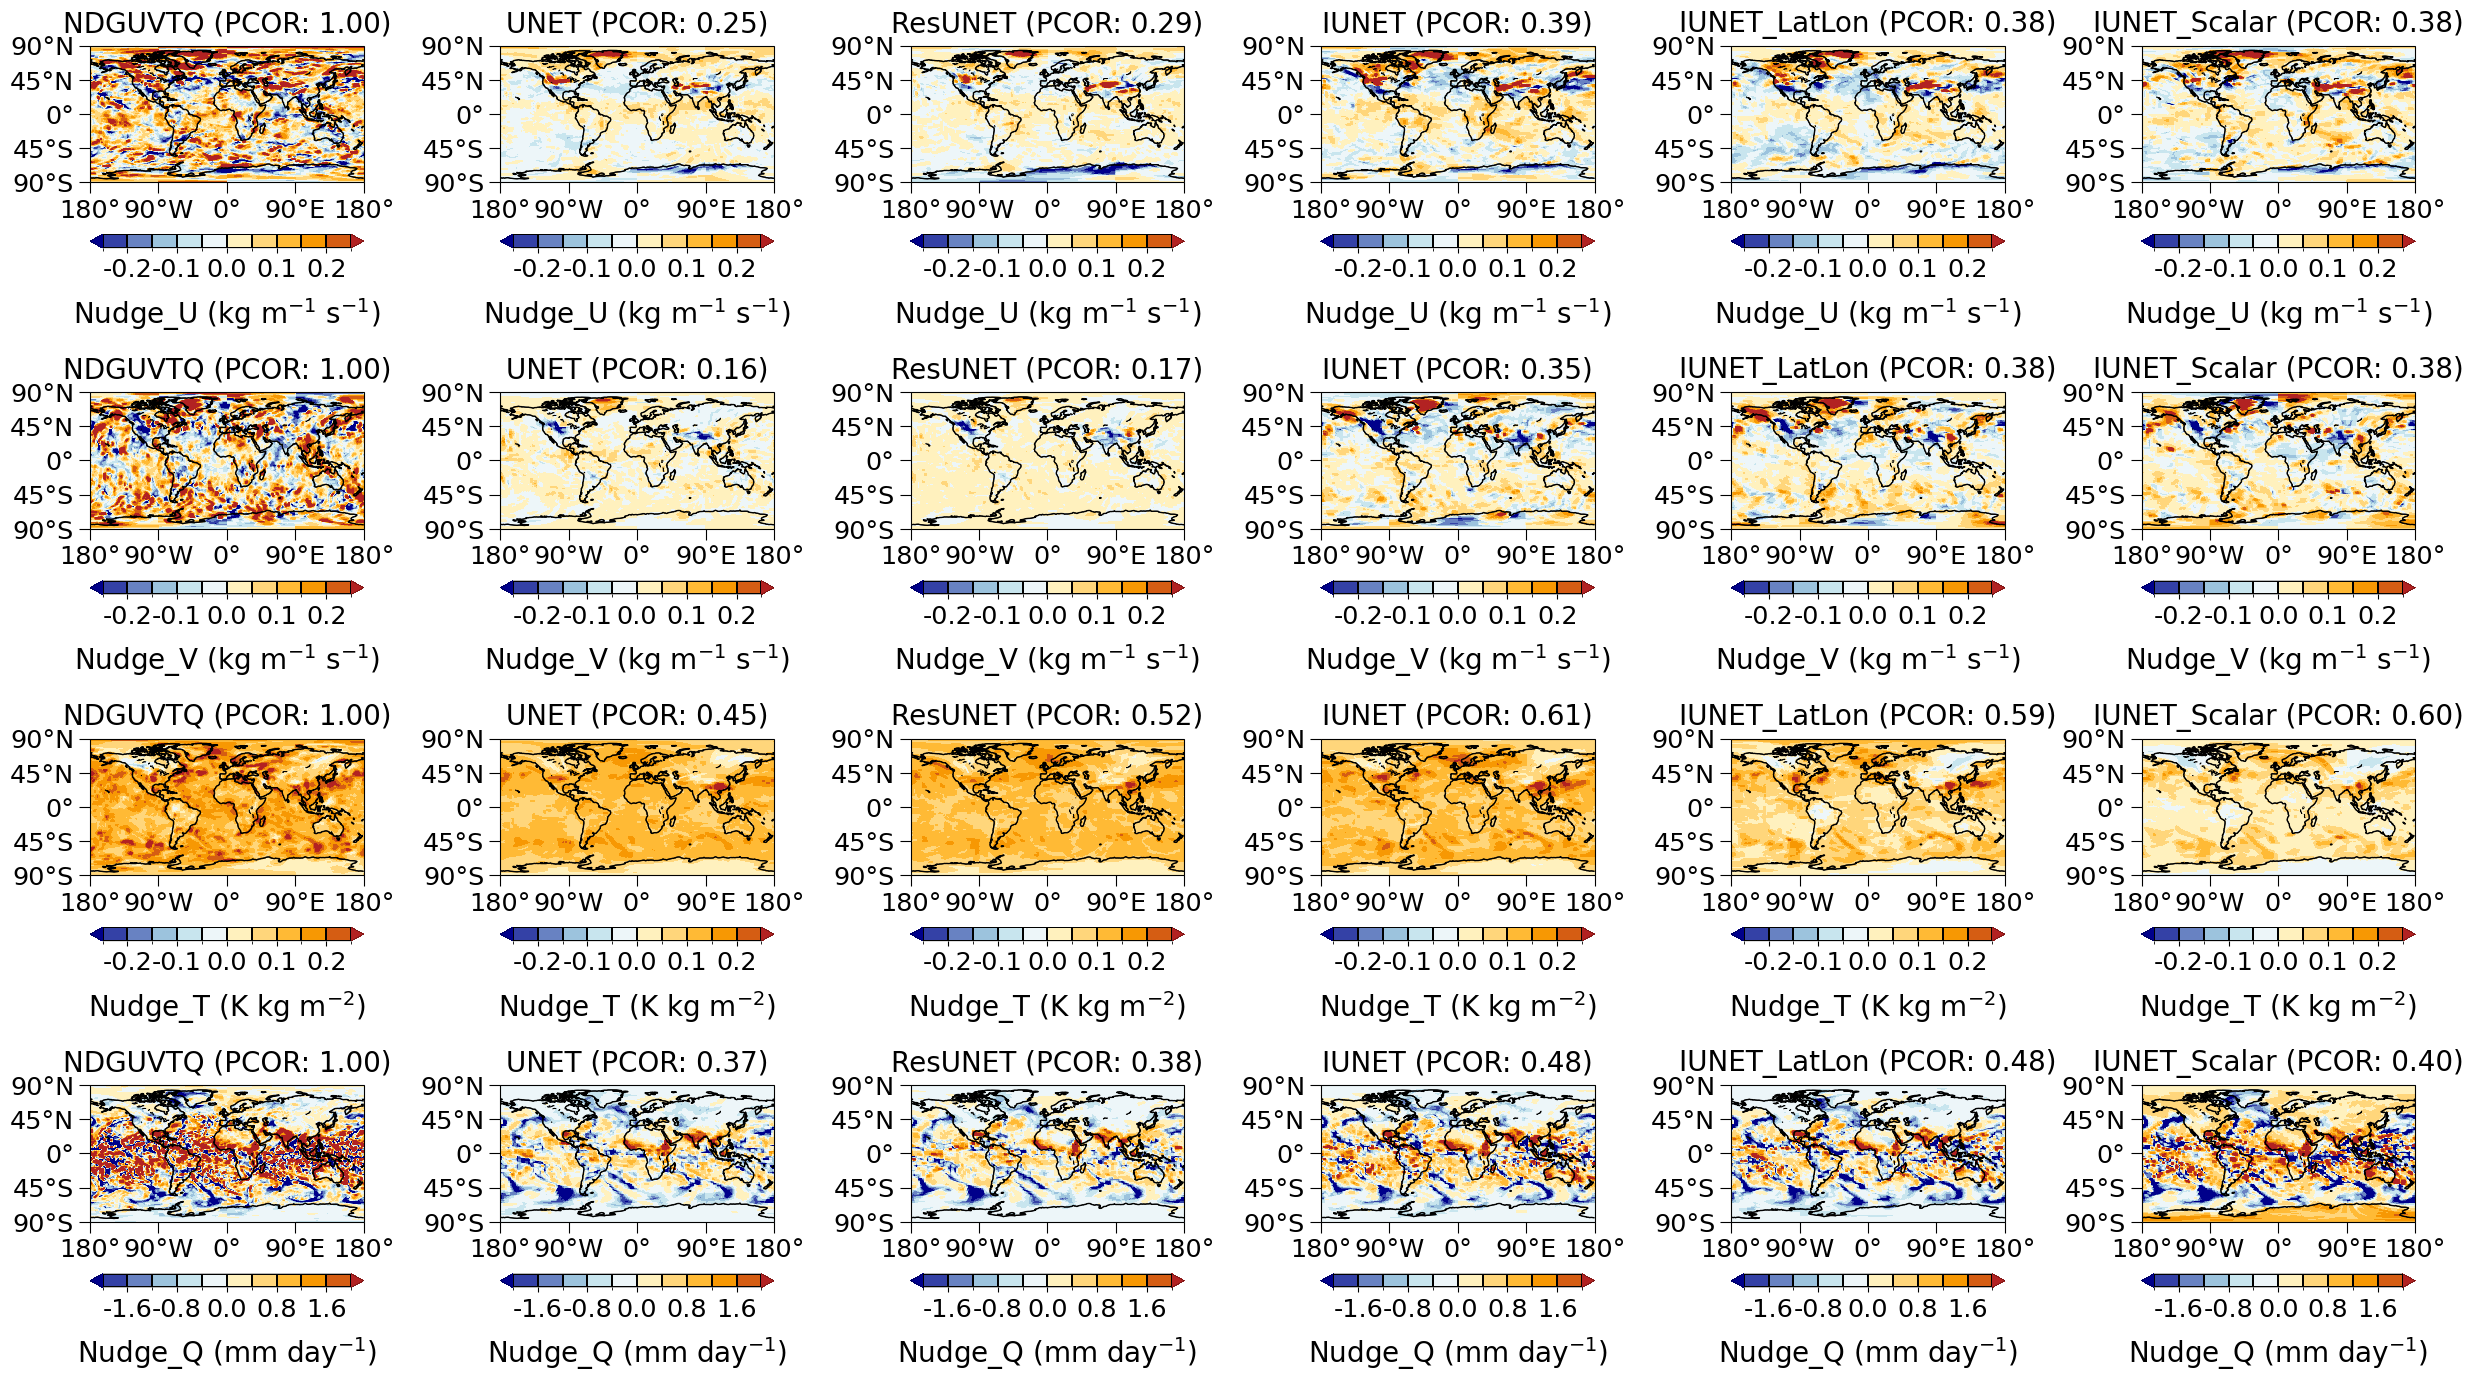

obs: 0.019248789770832612
Nudge_U NDGUVTQ PCOR: 1.00
Nudge_U UNET PCOR: 0.27
Nudge_U ResUNET PCOR: 0.31
Nudge_U IUNET PCOR: 0.42
Nudge_U IUNET_LatLon PCOR: 0.41
Nudge_U IUNET_Scalar PCOR: 0.41
obs: 0.016841020817329154
Nudge_V NDGUVTQ PCOR: 1.00
Nudge_V UNET PCOR: 0.17
Nudge_V ResUNET PCOR: 0.16
Nudge_V IUNET PCOR: 0.33
Nudge_V IUNET_LatLon PCOR: 0.36
Nudge_V IUNET_Scalar PCOR: 0.39
obs: 0.012270284306359718
Nudge_T NDGUVTQ PCOR: 1.00
Nudge_T UNET PCOR: 0.45
Nudge_T ResUNET PCOR: 0.51
Nudge_T IUNET PCOR: 0.60
Nudge_T IUNET_LatLon PCOR: 0.59
Nudge_T IUNET_Scalar PCOR: 0.63
obs: 6.082260115946031
Nudge_Q NDGUVTQ PCOR: 1.00
Nudge_Q UNET PCOR: 0.38
Nudge_Q ResUNET PCOR: 0.40
Nudge_Q IUNET PCOR: 0.51
Nudge_Q IUNET_LatLon PCOR: 0.49
Nudge_Q IUNET_Scalar PCOR: 0.46


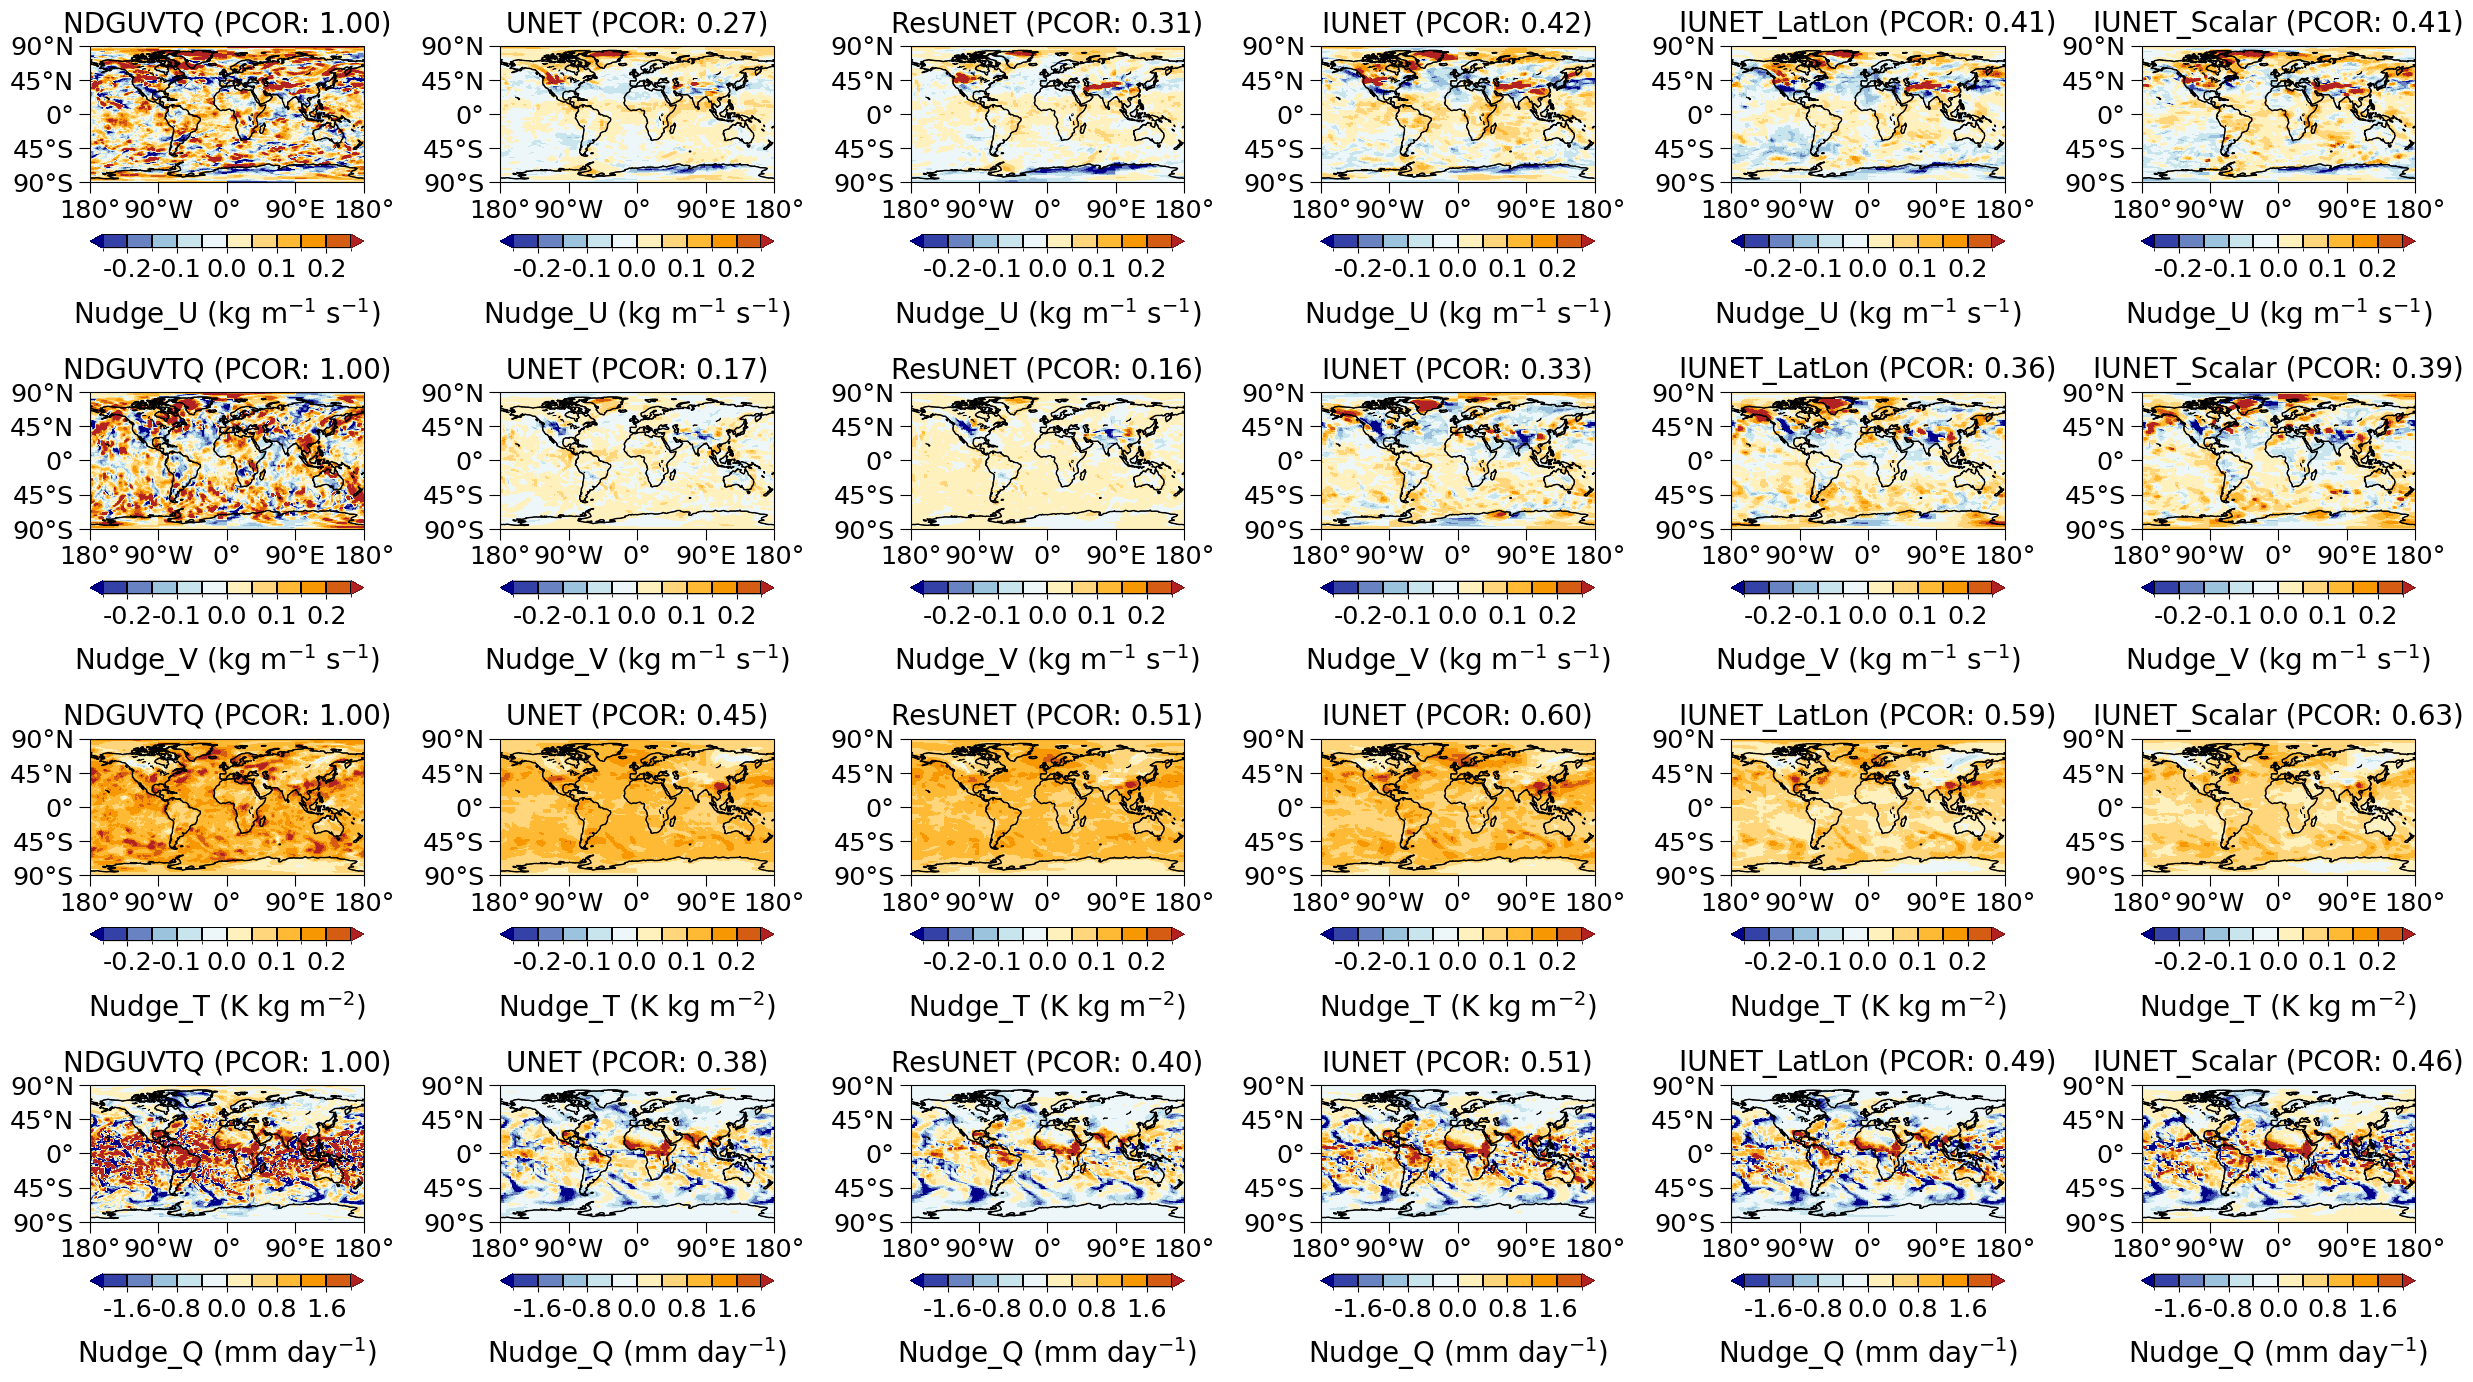

In [10]:
if __name__ == "__main__":
    top_path  = "/pscratch/sd/z/zhan391/SEACROGS_project/e3sm_model/machine_learning/fortran_e3sm_ml_glb"
    out_path  = os.path.join(top_path,"offline_evaluation","figure_data")
    fig_path  = os.path.join(top_path,"offline_evaluation","figures")
    refs      = {'ERA5': 'ERA5'}

    # region of interest (north Atlantic)
    regnam = "global" #'Atlantic'
    case_name = 'Sandy'
    case_year = 2012
    exp_dict = extract_offline_exp_info()
    
    tstart    = "2009-0001" # 00:00:0.0"
    tend      = "2009-0002" # 00:00:0.0"
    frequency = "3hourly"
    data_dict,var_dict = extract_ml_prediction(tstart,tend,exp_dict,out_path)
    for it in np.arange(5): 
        draw_2d_map(it,regnam,var_dict,data_dict,fig_path,fgw=30,fgh=18,ws=0.5,hs=0.0)
    